# Daily MTB22 histograms

For the stepfinder fit on the speed traces for the motors MotA/MotB of early experiments, we have the histograms per day as follows:

NB: The traces have been selected to avoid those that have clear photodamage

C:\Users\noepa\anaconda3\lib\site-packages\numpy\_distributor_init.py:30: UserWarning: loaded more than 1 DLL from .libs:
C:\Users\noepa\anaconda3\lib\site-packages\numpy\.libs\libopenblas.EL2C6PLE4ZYW3ECEVIV3OXXGRN2NRFM2.gfortran-win_amd64.dll
C:\Users\noepa\anaconda3\lib\site-packages\numpy\.libs\libopenblas64__v0.3.21-gcc_10_3_0.dll
  warnings.warn("loaded more than 1 DLL from .libs:"



📅 20250311 — GMM Fit
  Gaussian 1: mean = 118.42 Hz, std = 24.81 Hz
  Gaussian 2: mean = 179.30 Hz, std = 31.75 Hz


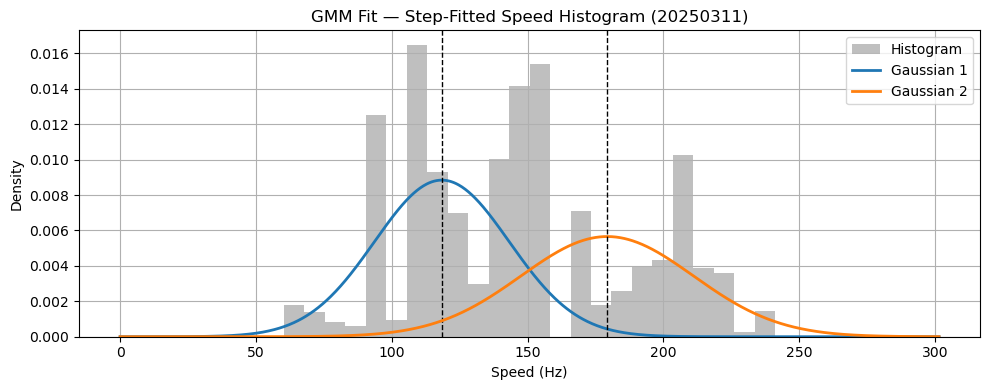


📅 20250313 — GMM Fit
  Gaussian 1: mean = 81.59 Hz, std = 17.85 Hz
  Gaussian 2: mean = 170.35 Hz, std = 35.21 Hz


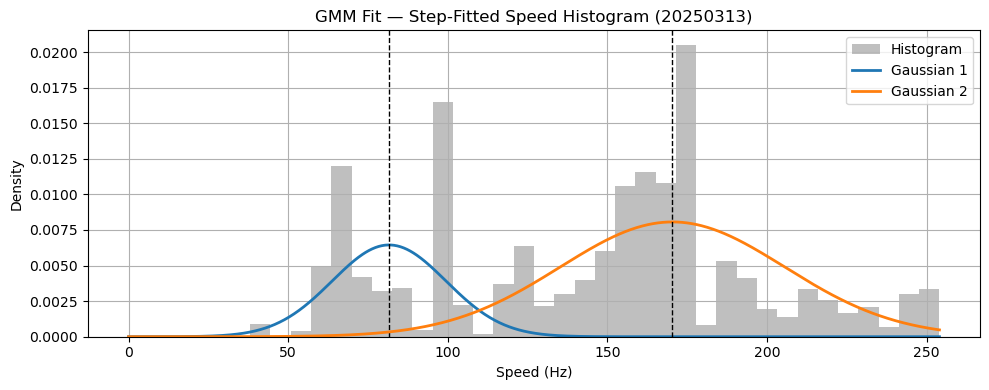


📅 20250320 — GMM Fit
  Gaussian 1: mean = 81.27 Hz, std = 16.85 Hz
  Gaussian 2: mean = 171.46 Hz, std = 50.99 Hz


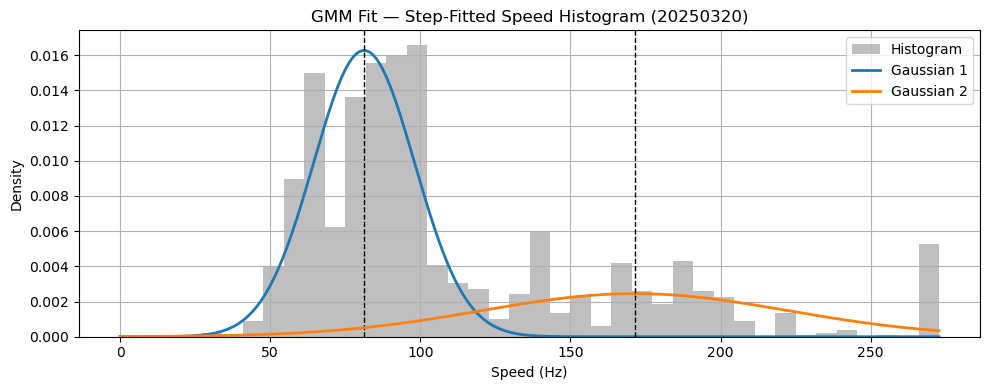


📅 20250325 — GMM Fit
  Gaussian 1: mean = 108.38 Hz, std = 31.83 Hz
  Gaussian 2: mean = 207.35 Hz, std = 26.05 Hz


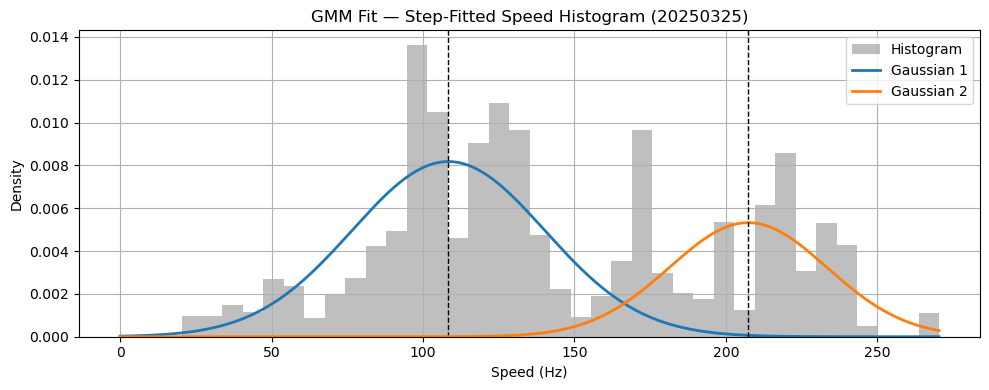

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from scipy.stats import norm

BASE_PATH = os.getcwd()

target_files = {
    "20250311": [
        "file_stepfinder_outputs",
        "file1_stepfinder_outputs",
        "file2_stepfinder_outputs",
        "file3_stepfinder_outputs"
    ],
    "20250313": [
        "file0224_stepfinder_outputs",
        # "file02225_stepfinder_outputs",  # optional
        "fileMinArab2_stepfinder_outputs",
        "fileMinArab3_stepfinder_outputs",
        "fileMinArab4_stepfinder_outputs"
    ], 
    "20250320": [
        "file_stepfinder_outputs",
        "file4_stepfinder_outputs",
        "file5_stepfinder_outputs",
        "file8_stepfinder_outputs",
        "file9_stepfinder_outputs",
        "file10_stepfinder_outputs",
        "file12_stepfinder_outputs",
        "file13_stepfinder_outputs",
        "file15_stepfinder_outputs",
        "file16_stepfinder_outputs",
        "file17_stepfinder_outputs"
    ],
    "20250325": [
        "file1_stepfinder_outputs",
        "file3_stepfinder_outputs",
        "file5_stepfinder_outputs",
        "file7_stepfinder_outputs",
        "file9_stepfinder_outputs",
        "file10_stepfinder_outputs",
        "file11_stepfinder_outputs",
        "file12_stepfinder_outputs",
        "file13_stepfinder_outputs"
    ]
}

def extract_stepfit_speeds(file_map):
    daily_speeds = {}
    for date_str, folder_list in file_map.items():
        all_speeds = []
        for folder_name in folder_list:
            path = os.path.join(BASE_PATH, date_str, "results", folder_name, "itot_speed_trace_stepfit.csv")
            if not os.path.exists(path):
                continue
            try:
                df = pd.read_csv(path)
                speeds = pd.to_numeric(df["Step-Fitted Speed (Hz)"], errors='coerce').dropna()
                all_speeds.extend(speeds.tolist())
            except Exception:
                continue
        if all_speeds:
            daily_speeds[date_str] = np.array(all_speeds)
    return daily_speeds

def plot_gmm_fit_per_day(daily_speeds):
    for date, speeds in daily_speeds.items():
        data = speeds.reshape(-1, 1)
        gmm = GaussianMixture(n_components=2, random_state=42)
        gmm.fit(data)
        weights = gmm.weights_
        means = gmm.means_.flatten()
        stds = np.sqrt(gmm.covariances_).flatten()

        # Sort for visual consistency
        sorted_indices = np.argsort(means)
        means = means[sorted_indices]
        stds = stds[sorted_indices]
        weights = weights[sorted_indices]

        # Print statistics
        print(f"\n📅 {date} — GMM Fit")
        for i, (mu, sigma) in enumerate(zip(means, stds)):
            print(f"  Gaussian {i+1}: mean = {mu:.2f} Hz, std = {sigma:.2f} Hz")

        # Plot histogram
        plt.figure(figsize=(10, 4))
        count, bins, _ = plt.hist(speeds, bins=40, density=True, alpha=0.5, color='gray', label="Histogram")

        # Overlay Gaussians
        x = np.linspace(min(speeds), max(speeds), 1000)
        for i in range(2):
            y = weights[i] * norm.pdf(x, means[i], stds[i])
            plt.plot(x, y, lw=2, label=f"Gaussian {i+1}")
            plt.axvline(means[i], color='k', linestyle='--', lw=1)
        
        plt.title(f"GMM Fit — Step-Fitted Speed Histogram ({date})")
        plt.xlabel("Speed (Hz)")
        plt.ylabel("Density")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

# Execute
daily_speeds = extract_stepfit_speeds(target_files)
plot_gmm_fit_per_day(daily_speeds)


# Global MTB22 Histogram

This histogram represents the raw summation of step-fitted speeds across all selected days. A possible bimodal structure is visible, but the peaks are not sharply resolved.

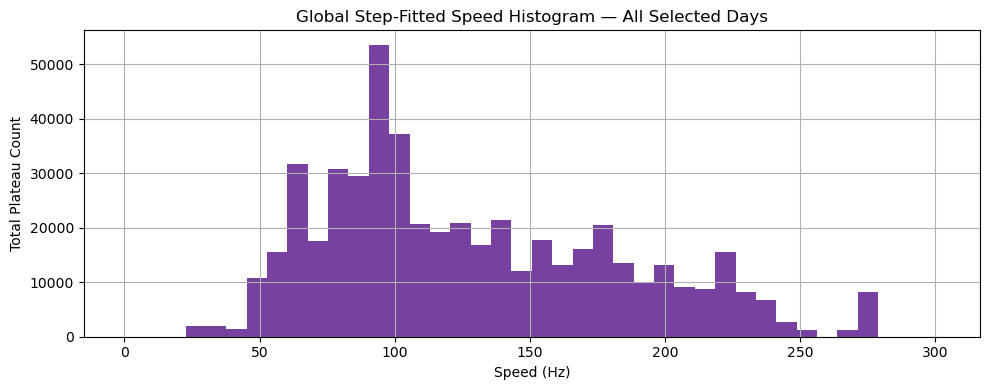

In [9]:
def plot_global_stepfit_histogram(file_map):
    all_speeds = []

    for date_str, folder_list in file_map.items():
        for folder_name in folder_list:
            path = os.path.join(BASE_PATH, date_str, "results", folder_name, "itot_speed_trace_stepfit.csv")
            if not os.path.exists(path):
                print(f"⚠️ Missing file: {path}")
                continue

            try:
                df = pd.read_csv(path)
                speeds = pd.to_numeric(df["Step-Fitted Speed (Hz)"], errors='coerce').dropna()
                all_speeds.extend(speeds.tolist())

            except Exception as e:
                print(f"❌ Error reading {path}: {e}")

    if all_speeds:
        plt.figure(figsize=(10, 4))
        plt.hist(all_speeds, bins=40, alpha=0.75, color='indigo')
        plt.title("Global Step-Fitted Speed Histogram — All Selected Days")
        plt.xlabel("Speed (Hz)")
        plt.ylabel("Total Plateau Count")
        plt.grid(True)
        plt.tight_layout()
        plt.show()
    else:
        print("⚠️ No usable stepfit data found in any folder.")

# Run it
plot_global_stepfit_histogram(target_files)


# Inferring GMM of two peaks for each day

To improve comparability across days, we first infer the two-peaked distribution of speeds for each day using a Gaussian Mixture Model (GMM).


📅 20250311 — GMM Fit
  Gaussian 1: mean = 118.42 Hz, std = 24.81 Hz
  Gaussian 2: mean = 179.30 Hz, std = 31.75 Hz


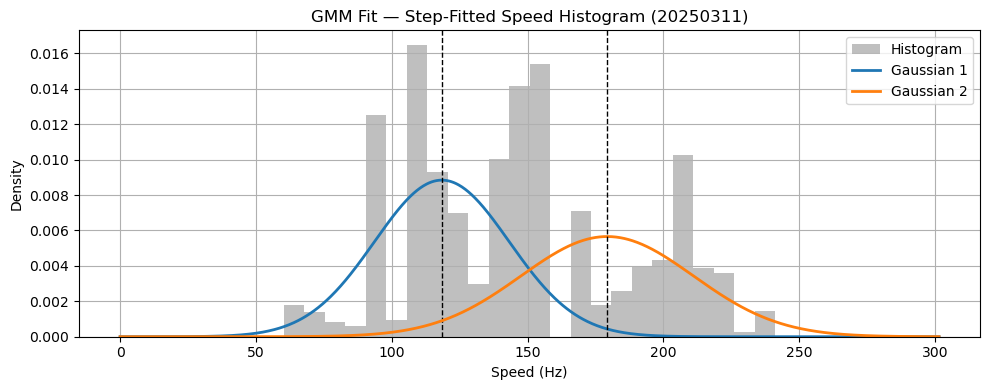


📅 20250313 — GMM Fit
  Gaussian 1: mean = 81.59 Hz, std = 17.85 Hz
  Gaussian 2: mean = 170.35 Hz, std = 35.21 Hz


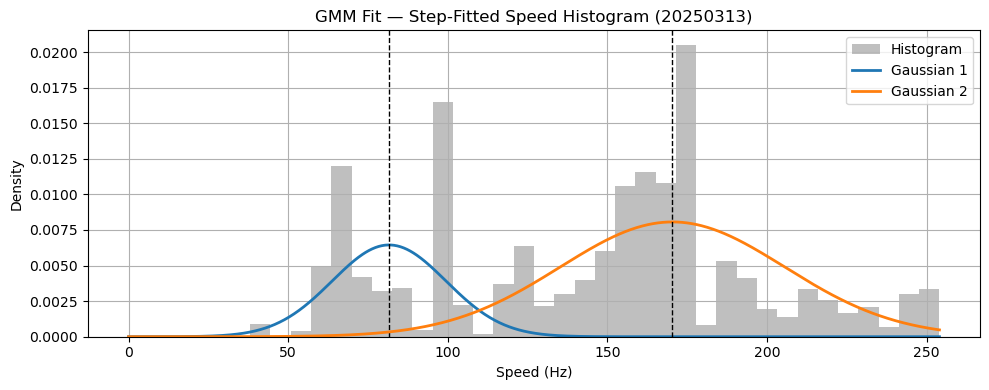


📅 20250320 — GMM Fit
  Gaussian 1: mean = 81.27 Hz, std = 16.85 Hz
  Gaussian 2: mean = 171.46 Hz, std = 50.99 Hz


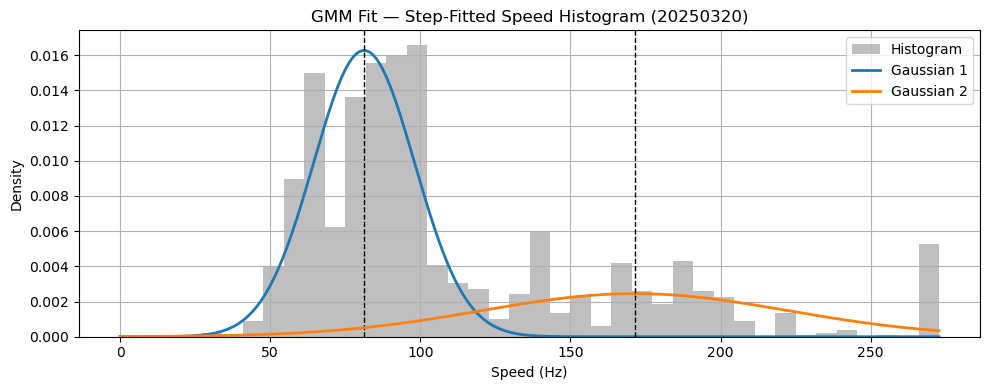


📅 20250325 — GMM Fit
  Gaussian 1: mean = 108.38 Hz, std = 31.83 Hz
  Gaussian 2: mean = 207.35 Hz, std = 26.05 Hz


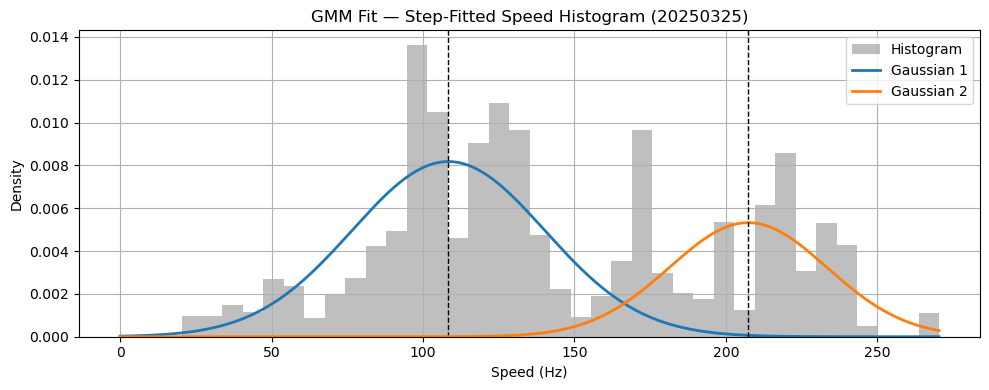

In [12]:
def plot_gmm_fit_per_day(daily_speeds):
    for date, speeds in daily_speeds.items():
        data = speeds.reshape(-1, 1)
        gmm = GaussianMixture(n_components=2, random_state=42)
        gmm.fit(data)
        weights = gmm.weights_
        means = gmm.means_.flatten()
        stds = np.sqrt(gmm.covariances_).flatten()

        # Sort for visual consistency
        sorted_indices = np.argsort(means)
        means = means[sorted_indices]
        stds = stds[sorted_indices]
        weights = weights[sorted_indices]

        # Print statistics
        print(f"\n📅 {date} — GMM Fit")
        for i, (mu, sigma) in enumerate(zip(means, stds)):
            print(f"  Gaussian {i+1}: mean = {mu:.2f} Hz, std = {sigma:.2f} Hz")

        # Plot histogram
        plt.figure(figsize=(10, 4))
        count, bins, _ = plt.hist(speeds, bins=40, density=True, alpha=0.5, color='gray', label="Histogram")

        # Overlay Gaussians
        x = np.linspace(min(speeds), max(speeds), 1000)
        for i in range(2):
            y = weights[i] * norm.pdf(x, means[i], stds[i])
            plt.plot(x, y, lw=2, label=f"Gaussian {i+1}")
            plt.axvline(means[i], color='k', linestyle='--', lw=1)
        
        plt.title(f"GMM Fit — Step-Fitted Speed Histogram ({date})")
        plt.xlabel("Speed (Hz)")
        plt.ylabel("Density")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

# Execute
daily_speeds = extract_stepfit_speeds(target_files)
plot_gmm_fit_per_day(daily_speeds)


# Smart Sum: Minimising distances between means of the GMMs

We combine speeds across days after aligning the two GMM-inferred means from each day's distribution. This minimizes inter-day variability and results in a clearer, more interpretable global histogram.


📊 Final Global GMM Fit — After Alignment
  Gaussian 1: mean = 104.07 Hz, std = 24.63 Hz
  Gaussian 2: mean = 194.21 Hz, std = 38.91 Hz


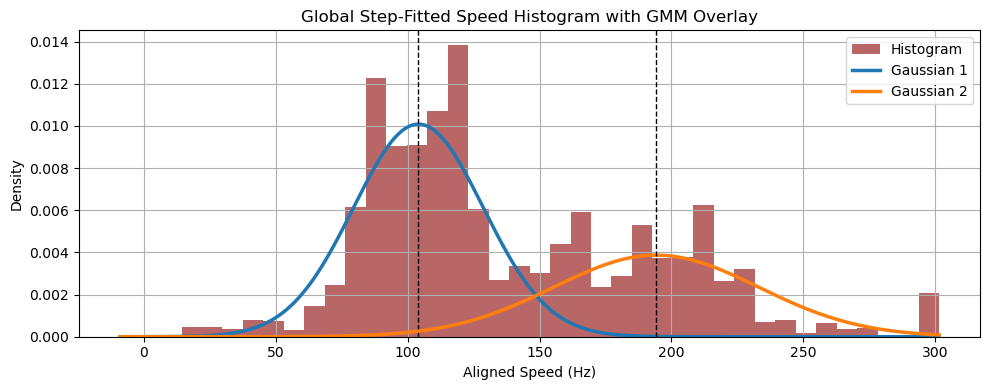

In [17]:
def fit_gmm_and_align(daily_speeds):
    """
    Fit 2-GMM to each day, align component means to reference day.
    """
    global_aligned_speeds = []
    reference_means = None

    for idx, (date, speeds) in enumerate(daily_speeds.items()):
        speeds_reshaped = speeds.reshape(-1, 1)

        # Fit 2-component GMM
        gmm = GaussianMixture(n_components=2, random_state=42)
        gmm.fit(speeds_reshaped)

        means = np.sort(gmm.means_.flatten())
        if idx == 0:
            reference_means = means
            shift = 0
        else:
            current_shift = np.mean(reference_means - means)
            speeds += current_shift  # Apply uniform shift
            means += current_shift  # Update for reference if needed

        global_aligned_speeds.extend(speeds)

    return global_aligned_speeds


def plot_global_histogram_with_gmm(aligned_speeds):
    """
    Plot merged, aligned histogram with 2-component GMM fit and annotated means.
    """
    # Fit GMM to all aligned data
    data = np.array(aligned_speeds).reshape(-1, 1)
    gmm = GaussianMixture(n_components=2, random_state=42)
    gmm.fit(data)

    weights = gmm.weights_
    means = gmm.means_.flatten()
    stds = np.sqrt(gmm.covariances_).flatten()

    # Sort for consistency
    sorted_indices = np.argsort(means)
    means = means[sorted_indices]
    stds = stds[sorted_indices]
    weights = weights[sorted_indices]

    # Print summary
    print("\n📊 Final Global GMM Fit — After Alignment")
    for i, (mu, sigma) in enumerate(zip(means, stds)):
        print(f"  Gaussian {i+1}: mean = {mu:.2f} Hz, std = {sigma:.2f} Hz")

    # Plot histogram
    plt.figure(figsize=(10, 4))
    count, bins, _ = plt.hist(aligned_speeds, bins=40, density=True, alpha=0.6, color='darkred', label="Histogram")

    # Overlay Gaussians
    x = np.linspace(min(aligned_speeds), max(aligned_speeds), 1000)
    for i in range(2):
        y = weights[i] * norm.pdf(x, means[i], stds[i])
        plt.plot(x, y, lw=2.5, label=f"Gaussian {i+1}", linestyle='-')
        plt.axvline(means[i], linestyle='--', color='k', lw=1)

    plt.title("Global Step-Fitted Speed Histogram with GMM Overlay")
    plt.xlabel("Aligned Speed (Hz)")
    plt.ylabel("Density")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Use it after alignment

# Run the pipeline
daily_speeds = extract_stepfit_speeds(target_files)
aligned_speeds = fit_gmm_and_align(daily_speeds)
plot_global_histogram_with_gmm(aligned_speeds)


If one wishes to be more rigurous, and exclude all the traces in which thare MAYBE is photodamage, then use the following list, replacing it at the beginning of this code. The code must be run in the same directory where you have the files named "20250313" for example.

In [ ]:
target_files = {
    "20250311": [
        "file_stepfinder_outputs",
        "file1_stepfinder_outputs"
    ],
    "20250313": [
        #"file02225_stepfinder_outputs",
        "fileMinArab2_stepfinder_outputs",
        "fileMinArab3_stepfinder_outputs",
        "fileMinArab4_stepfinder_outputs"
    ], 
    "20250320": [
        "file_stepfinder_outputs",
        "file5_stepfinder_outputs",
        "file8_stepfinder_outputs",
        "file12_stepfinder_outputs",
        "file13_stepfinder_outputs",
        "file15_stepfinder_outputs",
        "file16_stepfinder_outputs",
        "file17_stepfinder_outputs"
    ],
    "20250325": [
        "file7_stepfinder_outputs",
        "file12_stepfinder_outputs"
    ]
}
